# Stroke Prediction

## Problem Definition
Predicting whether a patient is likely to have a stroke based on demographic and health information.

- Learning type: Supervised Learning
- Problem type: Binary Classification
- Algorithm: Bagging (Bootstrap Aggregating)
- Target: stroke (0 = No Stroke, 1 = Stroke)

In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Abdel\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1


In [20]:
import os
import shutil

RAW_DATA_DIR = "../data/raw"
os.makedirs(RAW_DATA_DIR, exist_ok=True)

source_file = os.path.join(path, "healthcare-dataset-stroke-data.csv")
destination_file = os.path.join(RAW_DATA_DIR, "healthcare-dataset-stroke-data.csv")

shutil.copy(source_file, destination_file)

print("Data saved to:", destination_file)

Data saved to: ../data/raw\healthcare-dataset-stroke-data.csv


In [21]:
import pandas as pd

df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")

print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [23]:
df.describe(include="all")

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [24]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [25]:
df["stroke"].value_counts()
df["stroke"].value_counts(normalize=True) * 100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [26]:
df["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [27]:
df = df[df["gender"] != "Other"].reset_index(drop=True)

df["gender"].value_counts()

gender
Female    2994
Male      2115
Name: count, dtype: int64

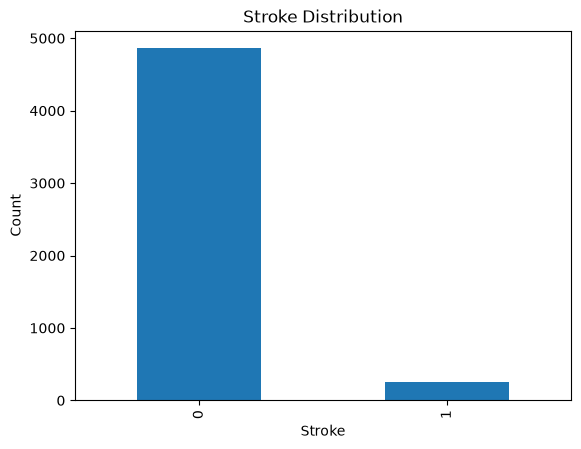

In [28]:
import matplotlib.pyplot as plt

df["stroke"].value_counts().plot(kind="bar")
plt.title("Stroke Distribution")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

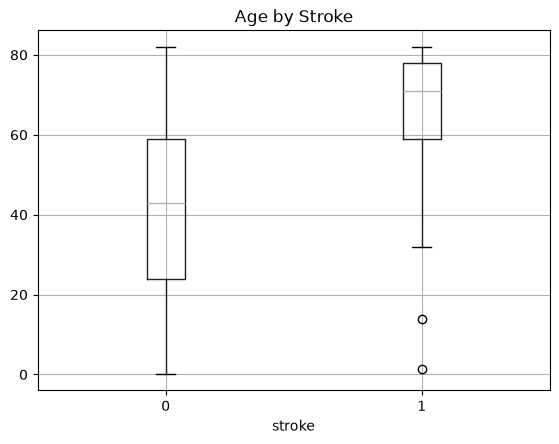

In [29]:
df.boxplot(column="age", by="stroke")
plt.title("Age by Stroke")
plt.suptitle("")
plt.show()

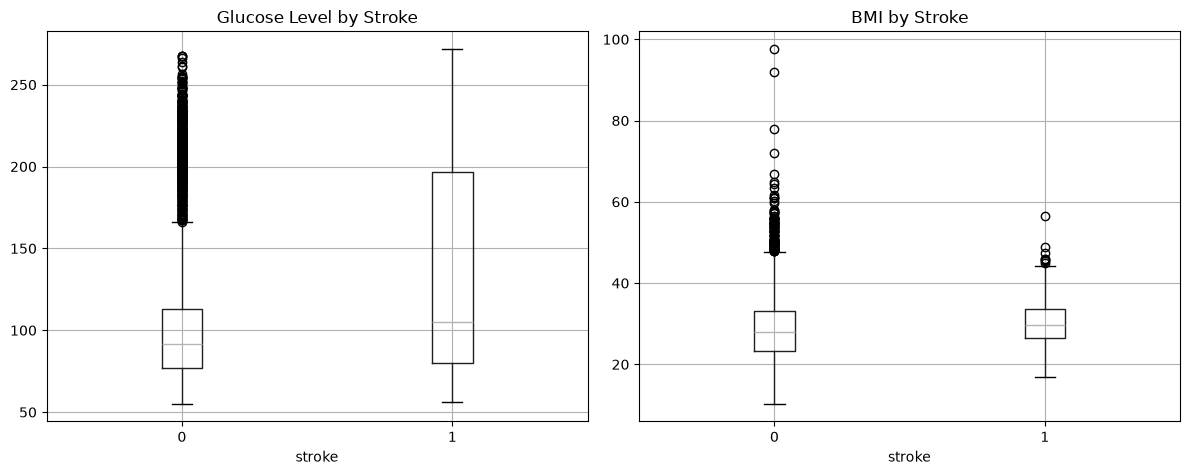

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column="avg_glucose_level", by="stroke", ax=axes[0])
axes[0].set_title("Glucose Level by Stroke")

df.boxplot(column="bmi", by="stroke", ax=axes[1])
axes[1].set_title("BMI by Stroke")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [31]:
pd.crosstab(df["hypertension"], df["stroke"], normalize="index") * 100

stroke,0,1
hypertension,,
0,96.031230,3.968770
1,86.746988,13.253012


In [32]:
pd.crosstab(df["heart_disease"], df["stroke"], normalize="index") * 100

stroke,0,1
heart_disease,,
0,95.820401,4.179599
1,82.971014,17.028986


In [33]:
pd.crosstab(df["smoking_status"], df["stroke"], normalize="index") * 100

stroke,0,1
smoking_status,,
Unknown,96.955959,3.044041
formerly smoked,92.081448,7.918552
never smoked,95.243129,4.756871
smokes,94.676806,5.323194


In [34]:
pd.crosstab(df["work_type"], df["stroke"], normalize="index") * 100

stroke,0,1
work_type,,
Govt_job,94.977169,5.022831
Never_worked,100.000000,0.000000
Private,94.904241,5.095759
Self-employed,92.063492,7.936508
children,99.708879,0.291121


In [35]:
pd.crosstab(df["ever_married"], df["stroke"], normalize="index") * 100

stroke,0,1
ever_married,,
No,98.348519,1.651481
Yes,93.438712,6.561288


In [ ]:

df["bmi"].isnull().sum()

np.int64(201)

In [37]:
df = df.drop(columns=["id"])

df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [38]:
X = df.drop(columns=["stroke"])

y = df["stroke"]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nTrain stroke %:\n", y_train.value_counts(normalize=True) * 100)
print("\nTest stroke %:\n", y_test.value_counts(normalize=True) * 100)

Train: (4087, 10) | Test: (1022, 10)

Train stroke %:
 stroke
0    95.130903
1     4.869097
Name: proportion, dtype: float64

Test stroke %:
 stroke
0    95.107632
1     4.892368
Name: proportion, dtype: float64


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_cols = ["age", "avg_glucose_level", "bmi"]
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
bin_cols = ["hypertension", "heart_disease"]   # already 0/1

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("bin", "passthrough", bin_cols),
])

In [41]:
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print("Train:", X_train_p.shape, "| Test:", X_test_p.shape)
print(feature_names)

Train: (4087, 20) | Test: (1022, 20)
['num__age' 'num__avg_glucose_level' 'num__bmi' 'cat__gender_Female'
 'cat__gender_Male' 'cat__ever_married_No' 'cat__ever_married_Yes'
 'cat__work_type_Govt_job' 'cat__work_type_Never_worked'
 'cat__work_type_Private' 'cat__work_type_Self-employed'
 'cat__work_type_children' 'cat__Residence_type_Rural'
 'cat__Residence_type_Urban' 'cat__smoking_status_Unknown'
 'cat__smoking_status_formerly smoked' 'cat__smoking_status_never smoked'
 'cat__smoking_status_smokes' 'bin__hypertension' 'bin__heart_disease']


In [42]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score)

def evaluate(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
    print("PR-AUC :", round(average_precision_score(y_test, y_proba), 3))
    return model

In [43]:
dummy = Pipeline([
    ("prep", clone(preprocessor)),
    ("clf", DummyClassifier(strategy="prior")),
])
evaluate(dummy, "Dummy Baseline");

===== Dummy Baseline =====
              precision    recall  f1-score   support

           0      0.951     1.000     0.975       972
           1      0.000     0.000     0.000        50

    accuracy                          0.951      1022
   macro avg      0.476     0.500     0.487      1022
weighted avg      0.905     0.951     0.927      1022

Confusion matrix:
 [[972   0]
 [ 50   0]]
ROC-AUC: 0.5
PR-AUC : 0.049


In [44]:
bag = Pipeline([
    ("prep", clone(preprocessor)),
    ("clf", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100, random_state=42, n_jobs=-1)),
])
evaluate(bag, "Bagging (plain)");

===== Bagging (plain) =====
              precision    recall  f1-score   support

           0      0.951     0.996     0.973       972
           1      0.000     0.000     0.000        50

    accuracy                          0.947      1022
   macro avg      0.475     0.498     0.486      1022
weighted avg      0.904     0.947     0.925      1022

Confusion matrix:
 [[968   4]
 [ 50   0]]
ROC-AUC: 0.767
PR-AUC : 0.122


In [45]:
bag_bal = Pipeline([
    ("prep", clone(preprocessor)),
    ("clf", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            class_weight="balanced", max_depth=5, min_samples_leaf=5, random_state=42),
        n_estimators=100, random_state=42, n_jobs=-1)),
])
evaluate(bag_bal, "Bagging (balanced trees)");

===== Bagging (balanced trees) =====
              precision    recall  f1-score   support

           0      0.988     0.779     0.871       972
           1      0.160     0.820     0.268        50

    accuracy                          0.781      1022
   macro avg      0.574     0.799     0.570      1022
weighted avg      0.948     0.781     0.842      1022

Confusion matrix:
 [[757 215]
 [  9  41]]
ROC-AUC: 0.84
PR-AUC : 0.215


In [46]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"recall": "recall", "precision": "precision", "f1": "f1",
           "roc_auc": "roc_auc", "pr_auc": "average_precision"}

for name, model in [("Bagging plain", bag), ("Bagging balanced", bag_bal)]:
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    print(name)
    for m in scoring:
        s = res[f"test_{m}"]
        print(f"  {m:10s}: {s.mean():.3f} ± {s.std():.3f}")

Bagging plain
  recall    : 0.025 ± 0.022
  precision : 0.173 ± 0.150
  f1        : 0.044 ± 0.039
  roc_auc   : 0.816 ± 0.024
  pr_auc    : 0.164 ± 0.021
Bagging balanced
  recall    : 0.679 ± 0.078
  precision : 0.136 ± 0.012
  f1        : 0.226 ± 0.020
  roc_auc   : 0.824 ± 0.029
  pr_auc    : 0.177 ± 0.032


In [47]:
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

proba_cv = cross_val_predict(bag_bal, X_train, y_train, cv=cv,
                             method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, proba_cv)
f2 = 5 * prec * rec / (4 * prec + rec + 1e-12)
best = np.argmax(f2[:-1])
best_thr = thr[best]
print(f"Best threshold: {best_thr:.3f} | CV precision: {prec[best]:.3f} | CV recall: {rec[best]:.3f}")

Best threshold: 0.554 | CV precision: 0.151 | CV recall: 0.633


In [48]:
bag_bal.fit(X_train, y_train)
y_proba = bag_bal.predict_proba(X_test)[:, 1]
y_pred_t = (y_proba >= best_thr).astype(int)

print(classification_report(y_test, y_pred_t, digits=3, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_t))

              precision    recall  f1-score   support

           0      0.985     0.813     0.891       972
           1      0.173     0.760     0.281        50

    accuracy                          0.810      1022
   macro avg      0.579     0.786     0.586      1022
weighted avg      0.945     0.810     0.861      1022

Confusion matrix:
 [[790 182]
 [ 12  38]]


In [49]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_samples": [0.5, 0.7, 1.0],
    "clf__max_features": [0.6, 0.8, 1.0],
    "clf__estimator__max_depth": [3, 4, 5, 6, 8],
    "clf__estimator__min_samples_leaf": [3, 5, 10, 20],
}

search = RandomizedSearchCV(
    bag_bal, param_dist, n_iter=25, cv=cv,
    scoring="average_precision", n_jobs=1, random_state=42,
)
search.fit(X_train, y_train)

print("Best CV PR-AUC:", round(search.best_score_, 3), "(baseline: 0.177)")
print(search.best_params_)

Best CV PR-AUC: 0.204 (baseline: 0.177)
{'clf__n_estimators': 300, 'clf__max_samples': 0.7, 'clf__max_features': 0.6, 'clf__estimator__min_samples_leaf': 10, 'clf__estimator__max_depth': 6}


In [50]:
best_model = search.best_estimator_

proba_cv = cross_val_predict(best_model, X_train, y_train, cv=cv,
                             method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, proba_cv)
f2 = 5 * prec * rec / (4 * prec + rec + 1e-12)
best_thr = thr[np.argmax(f2[:-1])]
print("Threshold:", round(best_thr, 3))

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= best_thr).astype(int)
print(classification_report(y_test, y_pred, digits=3, zero_division=0))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3),
      "| PR-AUC:", round(average_precision_score(y_test, y_proba), 3))

Threshold: 0.447
              precision    recall  f1-score   support

           0      0.983     0.782     0.871       972
           1      0.149     0.740     0.247        50

    accuracy                          0.780      1022
   macro avg      0.566     0.761     0.559      1022
weighted avg      0.942     0.780     0.841      1022

[[760 212]
 [ 13  37]]
ROC-AUC: 0.825 | PR-AUC: 0.212


In [51]:
from sklearn.metrics import recall_score, precision_score

rng = np.random.RandomState(42)
yt_all, yp_all, pr_all = y_test.values, y_pred, y_proba
rows = []
for _ in range(1000):
    idx = rng.randint(0, len(yt_all), len(yt_all))
    yt = yt_all[idx]
    if yt.sum() == 0:
        continue
    rows.append([
        recall_score(yt, yp_all[idx]),
        precision_score(yt, yp_all[idx], zero_division=0),
        average_precision_score(yt, pr_all[idx]),
        roc_auc_score(yt, pr_all[idx]),
    ])

ci = np.percentile(rows, [2.5, 97.5], axis=0)
for n, lo, hi in zip(["Recall", "Precision", "PR-AUC", "ROC-AUC"], ci[0], ci[1]):
    print(f"{n:10s}: 95% CI [{lo:.3f}, {hi:.3f}]")

Recall    : 95% CI [0.607, 0.860]
Precision : 95% CI [0.107, 0.193]
PR-AUC    : 95% CI [0.138, 0.319]
ROC-AUC   : 95% CI [0.766, 0.876]


In [52]:
from sklearn.inspection import permutation_importance

r = permutation_importance(best_model, X_test, y_test,
                           scoring="average_precision",
                           n_repeats=20, random_state=42, n_jobs=1)
imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)
print(imp.round(4))

age                  0.1186
heart_disease        0.0131
avg_glucose_level    0.0128
work_type            0.0075
bmi                  0.0063
Residence_type       0.0035
ever_married         0.0023
gender               0.0000
hypertension        -0.0034
smoking_status      -0.0058
dtype: float64


In [53]:
import joblib, os

os.makedirs("../models", exist_ok=True)
joblib.dump({"model": best_model, "threshold": float(best_thr)},
            "../models/stroke_bagging.joblib")
print("Saved.")

Saved.


In [54]:
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["y_pred"] = y_pred
test_df["proba"] = y_proba

test_df["outcome"] = np.select(
    [(test_df.y_true == 1) & (test_df.y_pred == 1),
     (test_df.y_true == 1) & (test_df.y_pred == 0),
     (test_df.y_true == 0) & (test_df.y_pred == 1)],
    ["TP", "FN", "FP"], default="TN")

print(test_df["outcome"].value_counts(), "\n")
cols = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "proba"]
print(test_df.groupby("outcome")[cols].mean().round(2))

outcome
TN    760
FP    212
TP     37
FN     13
Name: count, dtype: int64 

           age  avg_glucose_level    bmi  hypertension  heart_disease  proba
outcome                                                                     
FN       47.15             103.76  33.65          0.00           0.00   0.27
FP       68.33             135.64  30.05          0.31           0.11   0.56
TN       34.44              97.19  28.58          0.04           0.01   0.18
TP       75.30             148.87  28.81          0.32           0.30   0.60


In [55]:
display(test_df[test_df.outcome == "FN"].sort_values("proba", ascending=False))

test_df["age_band"] = pd.cut(test_df["age"], [0, 40, 60, 70, 100])
g = test_df.groupby("age_band", observed=True)
print(pd.DataFrame({
    "n": g.size(),
    "strokes": g["y_true"].sum(),
    "TP": g.apply(lambda d: ((d.y_true == 1) & (d.y_pred == 1)).sum()),
    "FP": g.apply(lambda d: ((d.y_true == 0) & (d.y_pred == 1)).sum()),
}))

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,y_true,y_pred,proba,outcome
222,Female,63.0,0,0,Yes,Govt_job,Rural,205.35,42.2,formerly smoked,1,0,0.429245,FN
194,Female,72.0,0,0,Yes,Private,Rural,97.92,26.9,smokes,1,0,0.428516,FN
190,Female,65.0,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1,0,0.424414,FN
80,Male,59.0,0,0,Yes,Private,Rural,96.16,44.1,Unknown,1,0,0.352557,FN
38,Male,58.0,0,0,No,Private,Rural,92.62,32.0,Unknown,1,0,0.351858,FN
133,Female,38.0,0,0,Yes,Private,Rural,101.45,NaN,formerly smoked,1,0,0.288632,FN
228,Female,39.0,0,0,Yes,Self-employed,Urban,97.76,29.6,smokes,1,0,0.234596,FN
94,Male,45.0,0,0,Yes,Private,Rural,64.14,29.4,never smoked,1,0,0.217642,FN
182,Female,32.0,0,0,Yes,Private,Rural,76.13,29.9,smokes,1,0,0.191266,FN
88,Male,47.0,0,0,Yes,Private,Urban,86.94,41.1,formerly smoked,1,0,0.187120,FN


             n  strokes  TP  FP
age_band                       
(0, 40]    448        5   0   0
(40, 60]   316        7   2  61
(60, 70]   122        7   5  54
(70, 100]  136       31  30  97
